# AFL Match Context Integration

**Objective:** The round-by-round player dataset has no information about *where* or *under what conditions* each match was played. This notebook enriches it with `home_away`, `venue`, and `crowd` from the team matches dataset, so we can test whether match context (playing at home, crowd size, venue) actually affects player performance.

**Approach:** This notebook merges the **entire history** of both datasets. A bigger, multi-decade sample gives a far more reliable read on structural questions like "is there a real home-ground advantage" than a single season would.

## 0. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
os.makedirs("day5_charts", exist_ok=True)

rbr_raw = pd.read_csv("afl_players_round_by_round_stats_raw.csv", low_memory=False)
match_raw = pd.read_csv("team_matches_home_away_raw.csv")

print("Round-by-round shape:", rbr_raw.shape)
print("Team matches shape:", match_raw.shape)

Round-by-round shape: (274089, 36)
Team matches shape: (15808, 19)


Two separate raw sources, two separate stories. The round-by-round file is *player-centric*, i.e. one row per player per match. The team matches file is *team-centric*, i.e. one row per team per match (so a single game produces 2 rows in this file, one for each side). Before anything else, load both and just look at their shape; you can't plan a merge strategy without knowing how big and how differently-structured each side is.

## 0.1 Round-by-Round Cleaning

In [3]:
rbr = rbr_raw.drop_duplicates().drop(columns=['score'])

has_both = rbr['kicks'].notna() & rbr['handballs'].notna()
rbr.loc[has_both, 'disposals'] = rbr.loc[has_both, 'kicks'] + rbr.loc[has_both, 'handballs']

count_cols = ['kicks','marks','handballs','disposals','goals','behinds','hit_outs','tackles',
              'rebound_50s','inside_50s','clearances','clangers','free_kicks_for','free_kicks_against',
              'brownlow_votes','contested_possessions','uncontested_possessions','contested_marks',
              'marks_inside_50','one_percenters','bounces','goal_assist']
rbr[count_cols] = rbr[count_cols].fillna(0)

overall_median_pct = rbr['percentage_of_game_played'].median()
rbr['percentage_of_game_played'] = rbr.groupby('player_id')['percentage_of_game_played'].transform(lambda s: s.fillna(s.median()))
rbr['percentage_of_game_played'] = rbr['percentage_of_game_played'].fillna(overall_median_pct)

finals_order = {'EF': 25, 'QF': 26, 'SF': 27, 'PF': 28, 'GF': 29}
def round_to_num(r):
    r = str(r).strip()
    if r in finals_order:
        return finals_order[r]
    try:
        return int(r)
    except ValueError:
        return np.nan
rbr['round_number'] = rbr['round'].apply(round_to_num)
rbr['is_trial_match'] = rbr['round'] == '0'

# Trial matches aren't real competition games, so they're excluded before any merge/analysis
rbr = rbr[~rbr['is_trial_match']].copy()

assert rbr.isna().sum().sum() == 0, "still missing values!"
print("Cleaned round-by-round shape:", rbr.shape)

Cleaned round-by-round shape: (273803, 37)


## 0.2 Team Matches — Initial Data Quality Assessment

In [4]:
print("Shape:", match_raw.shape)
print("\nMissing values:")
print(match_raw.isna().sum()[match_raw.isna().sum() > 0])
print("\nDuplicate rows:", match_raw.duplicated().sum())
print("\nUnique team_name values (raw):", match_raw['team_name'].nunique(), "-- should be ~20")
print(sorted(match_raw['team_name'].unique())[:6])
print("\nUnique venue values (raw):", match_raw['venue'].nunique(), "-- should be ~15-20 real stadiums")
print("\nhome_away values:", match_raw['home_away'].unique())

Shape: (15808, 19)

Missing values:
crowd    398
dtype: int64

Duplicate rows: 0

Unique team_name values (raw): 40 -- should be ~20
['\t Adelaide Crows ', '\tBrisbane Bears', '\tBrisbane Lions', '\tCarlton Blues', '\tCollingwood Magpies', '\tEssendon Bombers']

Unique venue values (raw): 64 -- should be ~15-20 real stadiums

home_away values: <StringArray>
['A', 'H']
Length: 2, dtype: str


**Observations:**
- `team_name` returns far more than 20 unique values — every team appears at least twice, once clean and once with leading/trailing whitespace or a tab character.
- `venue` returns 64 unique values despite the AFL using roughly 15–20 primary stadiums — trailing `\n` characters are splitting single venues into two categories.
- `crowd` has 398 missing values, concentrated (as we'll confirm later) around the COVID-affected 2020/2021 seasons.
- `"W. Bulldogs"` is a separate, inconsistent name for the team the round-by-round dataset calls `"Western Bulldogs"`.

## Task 1: Relationship Discovery

Before writing any merge code, we need to know two things: which columns exist in *both* tables, and whether any single one of them is unique enough to safely join on. A merge key that isn't unique on at least one side of the join will silently multiply rows, that quietly corrupts a dataset.

In [15]:
rbr_cols = set(rbr.columns)
match_cols = set(match_raw.columns)
common_cols = rbr_cols & match_cols
print("Common column names:", common_cols)


Common column names: {'id', 'round', 'opponent', 'match_date', 'year', 'result', 'margin'}


In [14]:
# team_name (matches) corresponds to team (round-by-round) - not identical names,
# but the same real-world field, so it counts as a shared key candidate too.
print("\nIs 'match_date' unique in matches on its own?", match_raw['match_date'].is_unique)
print("Is 'round' unique in matches on its own?", match_raw['round'].is_unique)
print("Is 'team_name' unique in matches on its own?", match_raw['team_name'].is_unique)


Is 'match_date' unique in matches on its own? False
Is 'round' unique in matches on its own? False
Is 'team_name' unique in matches on its own? False


## Insights 
The `&` operator between two sets returns their **intersection**: everything present in both. This is a fast way to spot shared fields without manually eyeballing two long column lists side by side.

`.is_unique` is a quick built-in check — `True` only if every value in that column appears exactly once. All three return `False` here, which already tells us no single column can be the merge key on its own: `match_date` repeats because multiple different matches happen on the same date across the league; `round` repeats because every team plays every round, every year; `team_name` repeats because each team plays hundreds of matches across the dataset's history.

**Conclusion so far:** since no single field is unique, a **composite key** (a combination of 2+ columns) is required.

In [16]:
# Test the two most obvious composite key candidates
dup_a = match_raw.duplicated(subset=['team_name', 'year', 'round']).sum()
dup_b = match_raw.duplicated(subset=['team_name', 'match_date']).sum()
print("Duplicates with team_name + year + round:", dup_a)
print("Duplicates with team_name + match_date:", dup_b)

# Inspect the team_name + year + round duplicates directly
dups = match_raw[match_raw.duplicated(subset=['team_name', 'year', 'round'], keep=False)]
dups_clean_names = dups.copy()
dups_clean_names['team_name'] = dups_clean_names['team_name'].str.strip()
print("\nRows involved in the team+year+round clash:")
print(dups_clean_names[['team_name', 'year', 'round', 'match_date', 'opponent', 'result']].sort_values(['team_name','year','round']))

Duplicates with team_name + year + round: 6
Duplicates with team_name + match_date: 0

Rows involved in the team+year+round clash:
                 team_name  year round  match_date             opponent result
15156  Collingwood Magpies  1990    QF  1990-09-08    west coast eagles      D
15157  Collingwood Magpies  1990    QF  1990-09-15    west coast eagles      W
2160   Collingwood Magpies  2010    GF  2010-09-25      St Kilda Saints      D
2161   Collingwood Magpies  2010    GF  2010-10-02      St Kilda Saints      W
3051      Essendon Bombers  2025    24  2025-08-21        Carlton Blues      L
3052      Essendon Bombers  2025    24  2025-08-27      Gold Coast Suns      L
4414       Gold Coast Suns  2025    24  2025-08-22  Port Adelaide Power      L
4415       Gold Coast Suns  2025    24  2025-08-27     Essendon Bombers      W
7458       St Kilda Saints  2010    GF  2010-09-25  Collingwood Magpies      D
7459       St Kilda Saints  2010    GF  2010-10-02  Collingwood Magpies      L


**Observations:** `team_name + year + round` almost works (only 6 duplicated combinations out of 15,808 rows) but isn't fully safe. Looking at the actual rows:
- Two pairs are **drawn finals that were replayed a week later** (same team, same year, same round code, genuinely two different matches).
- Two more pairs are **Essendon and Gold Coast Suns playing twice in the same round** — a real-world scheduling quirk (a postponed/rescheduled fixture landing in the same round number as another game).

`team_name + match_date` has **zero duplicates** — since a team can only play one match on any given date, this is the safe, unique composite key. `match_date` also implicitly encodes the year, so nothing is lost by dropping `year` and `round` from the key itself.

**Task 1 Answer:** The chosen merge key is **`team_name` + `match_date`** (matching to `team` + `match_date` on the round-by-round side). It's the simplest composite key that's provably unique — confirmed by zero duplicate combinations — and it naturally sidesteps the drawn-final and rescheduled-match edge cases that break `team_name + year + round`.

## Cleaning the Team Matches Dataset

In [17]:
matches = match_raw.copy()

# Fix whitespace/tab issues and the "W. Bulldogs" naming mismatch
matches['team_name'] = matches['team_name'].str.strip().replace({'W. Bulldogs': 'Western Bulldogs'}).str.title()
matches['opponent'] = matches['opponent'].str.strip().replace({'W. Bulldogs': 'Western Bulldogs'}).str.title()

# Fix trailing newline characters splitting venues into duplicate categories
matches['venue'] = matches['venue'].str.strip()

print("team_name unique after cleaning:", matches['team_name'].nunique())
print("venue unique after cleaning:", matches['venue'].nunique())

rbr_teams = set(rbr['team'].unique())
match_teams = set(matches['team_name'].unique())
print("\nStill mismatched after cleaning:")
print("In round-by-round but not matches:", rbr_teams - match_teams)
print("In matches but not round-by-round:", match_teams - rbr_teams)

print("\nDuplicates with team_name + match_date (should be 0):", matches.duplicated(subset=['team_name','match_date']).sum())

team_name unique after cleaning: 20
venue unique after cleaning: 37

Still mismatched after cleaning:
In round-by-round but not matches: set()
In matches but not round-by-round: set()

Duplicates with team_name + match_date (should be 0): 0


The two empty-set results (`set() `and `set()`) confirm every team name now matches exactly between the two datasets.

In [18]:
merged = rbr.merge(
    matches[['team_name', 'match_date', 'home_away', 'venue', 'crowd']],
    left_on=['team', 'match_date'],
    right_on=['team_name', 'match_date'],
    how='left',
    indicator=True 
)
merged = merged.drop(columns=['team_name'])

print("Merged shape:", merged.shape)
merged[['team','match_date','home_away','venue','crowd']].head()

Merged shape: (273803, 41)


,team,match_date,home_away,venue,crowd
0,Hawthorn Hawks,1994-08-14,A,Melbourne Cricket Ground,52562.0
1,Geelong Cats,2024-03-16,H,GMHBA Stadium,39352.0
2,Essendon Bombers,1999-06-04,A,AAMI Stadium,39389.0
3,Western Bulldogs,1994-08-13,A,Waverley Park,14653.0
4,Richmond Tigers,1997-05-31,H,Melbourne Cricket Ground,28879.0


In [19]:
# Spot-check: pick one row and manually confirm it against the source matches table
sample = merged.iloc[0]
print("Player row:", sample['team'], sample['match_date'], "-->", 
      sample['home_away'], sample['venue'], sample['crowd'])

check = matches[(matches['team_name'] == sample['team']) & (matches['match_date'] == sample['match_date'])]
print("\nMatching row in the matches dataset:")
print(check[['team_name', 'match_date', 'home_away', 'venue', 'crowd']])

Player row: Hawthorn Hawks 1994-08-14 --> A Melbourne Cricket Ground 52562.0

Matching row in the matches dataset:
            team_name  match_date home_away                     venue    crowd
10717  Hawthorn Hawks  1994-08-14         A  Melbourne Cricket Ground  52562.0


## Task 3: Merge Validation


In [10]:
print("Rows before merge:", rbr.shape[0])
print("Rows after merge:", merged.shape[0])
print("Row count unchanged:", rbr.shape[0] == merged.shape[0])

print("\n_merge breakdown:")
print(merged['_merge'].value_counts())

unmatched = merged[merged['_merge'] == 'left_only']
print("\nUnmatched player rows:", len(unmatched))

merged = merged.drop(columns=['_merge'])
print("\nDuplicate rows introduced by the merge:", merged.duplicated().sum())
print("\nMissing values in the new columns:")
print(merged[['home_away','venue','crowd']].isna().sum())

Rows before merge: 273803
Rows after merge: 273803
Row count unchanged: True

_merge breakdown:
_merge
both          273803
left_only          0
right_only         0
Name: count, dtype: int64

Unmatched player rows: 0

Duplicate rows introduced by the merge: 0

Missing values in the new columns:
home_away       0
venue           0
crowd        8955
dtype: int64


**Observations:**
- Row count is **unchanged**: 273,803 before, 273,803 after.
- **Zero unmatched rows** — every player row found a matching team/date combination in the matches dataset. This is a direct payoff of the team-name and venue cleaning done earlier; before that cleaning, any team affected by the whitespace or `"W. Bulldogs"` issue would have silently failed to match.
- **Zero duplicate rows** introduced by the merge, confirming `team + match_date` really is a safe, unique key.
- `home_away` and `venue` have no missing values (every match has this recorded), but `crowd` does, 398 matches missing `crowd` at the match level now show up as roughly 8,955 missing values at the player-row level, since each match expands into one row per player who played in it. This is expected, not a merge bug.

## Task 4: Contextual Analysis

### 4.1 Do players perform better at home or away?

home_away
A    64.007430
H    66.486577
Name: fantasy_points, dtype: float64

Home advantage: 2.48 fantasy points


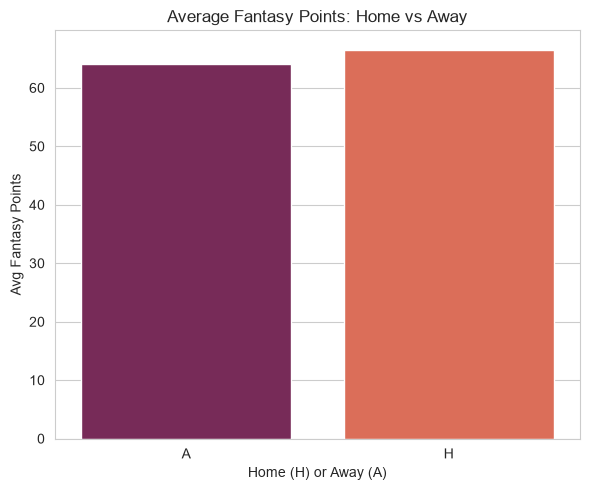

In [11]:
home_away_avg = merged.groupby('home_away')['fantasy_points'].mean()
print(home_away_avg)
print("\nHome advantage:", round(home_away_avg['H'] - home_away_avg['A'], 2), "fantasy points")

plt.figure(figsize=(6, 5))
sns.barplot(x=home_away_avg.index, y=home_away_avg.values, hue=home_away_avg.index, palette="rocket", legend=False)
plt.title("Average Fantasy Points: Home vs Away")
plt.xlabel("Home (H) or Away (A)")
plt.ylabel("Avg Fantasy Points")
plt.tight_layout()
plt.savefig("day5_charts/01_home_vs_away.png", dpi=100)
plt.show()

 `groupby('home_away')['fantasy_points'].mean()` is the simplest possible test of a "does X affect Y" question. It split all rows into their two groups (home / away) and compare the average outcome between them.

**Observations:** Players average **66.5** fantasy points at home vs **64.0** away — a **~2.5 point** gap. It's not a huge swing, but it's a consistent, real one across the entire multi-decade dataset, lining up with the general idea of home-ground advantage: familiar surroundings, no travel fatigue, and crowd support.

A 2.5-points gap is small individually, but summed across 22 players on a team over a season, home-ground advantage is a real, measurable factor, supporting the value of things like scheduling more home finals for higher-seeded teams.

### 4.2 Does crowd size appear to influence fantasy points?

Correlation between crowd size and fantasy points: 0.0129
crowd_bucket
Low crowd         65.295945
Med-Low crowd     64.749698
Med-High crowd    65.824455
High crowd        66.092489
Name: fantasy_points, dtype: float64


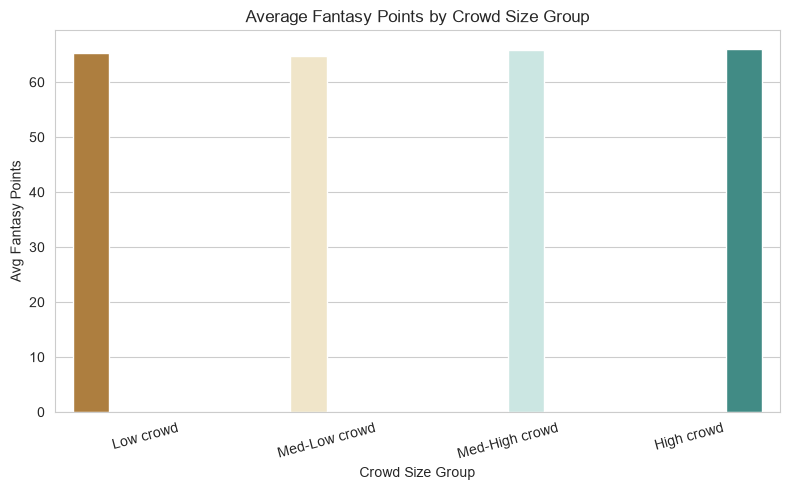

In [32]:
valid = merged.dropna(subset=['crowd', 'fantasy_points'])
correlation = valid['crowd'].corr(valid['fantasy_points'])
print("Correlation between crowd size and fantasy points:", round(correlation, 4))

valid = valid.copy()
valid['crowd_bucket'] = pd.qcut(valid['crowd'], 4, labels=['Low crowd', 'Med-Low crowd', 'Med-High crowd', 'High crowd'])
crowd_avg = valid.groupby('crowd_bucket', observed=True)['fantasy_points'].mean()
print(crowd_avg)

plt.figure(figsize=(8, 5))
sns.barplot(x=crowd_avg.index, y=crowd_avg.values, hue=crowd_avg.index, palette='BrBG')
plt.title("Average Fantasy Points by Crowd Size Group")
plt.xlabel("Crowd Size Group")
plt.ylabel("Avg Fantasy Points")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("day5_charts/02_crowd_size_groups.png", dpi=100)
plt.show()

Crowd size does not meaningfully influence individual player output. Bigger games (finals, rivalry matches) naturally draw bigger crowds, but that doesn't translate into players scoring higher or lower, so crowd size isn't a factor worth building into any player-performance model.

### 4.3 Which venues produce the highest average player performance?

venue
UTAS Stadium                68.05
ENGIE Stadium               67.89
Marvel Stadium              67.57
Adelaide Oval               67.53
TIO Stadium                 67.10
Ninja Stadium               67.01
Optus Stadium               66.12
People First Stadium        65.99
Melbourne Cricket Ground    65.46
GMHBA Stadium               65.24
Manuka Oval                 65.22
Domain Stadium              65.20
Accor Stadium               64.97
The Gabba                   63.59
AAMI Stadium                62.89
Sydney Cricket Ground       62.81
Western Oval                59.71
Waverley Park               59.23
Princes Park                58.47
WACA                        58.41
Name: fantasy_points, dtype: float64


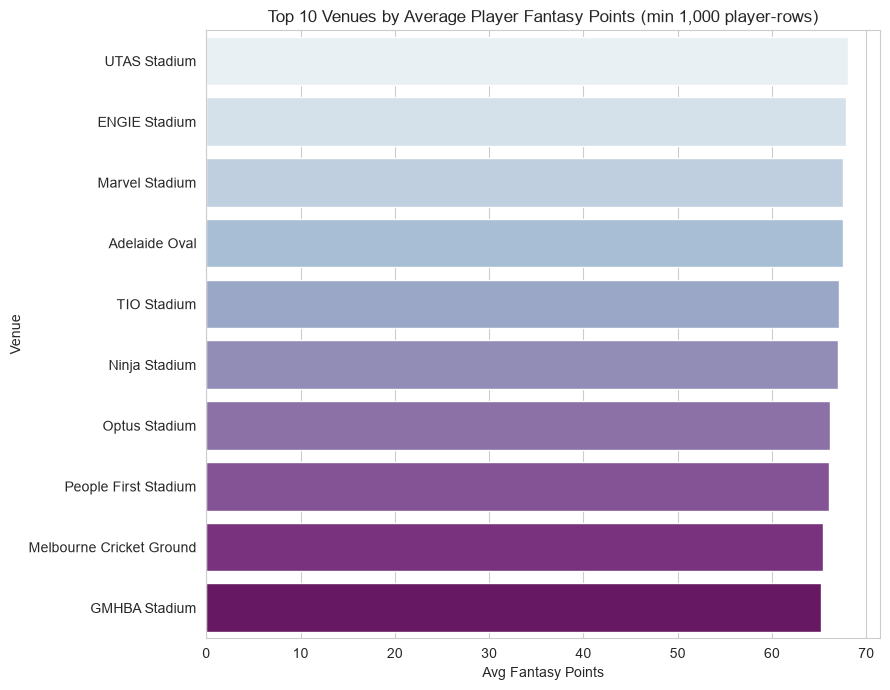

In [37]:
venue_counts = merged['venue'].value_counts()
common_venues = venue_counts[venue_counts >= 1000].index

venue_avg = merged[merged['venue'].isin(common_venues)].groupby('venue')['fantasy_points'].mean().sort_values(ascending=False)
print(venue_avg.round(2))

plt.figure(figsize=(9, 7))
sns.barplot(y=venue_avg.head(10).index, x=venue_avg.head(10).values, hue=venue_avg.head(10).index, palette='BuPu', legend=False)
plt.title("Top 10 Venues by Average Player Fantasy Points (min 1,000 player-rows)")
plt.xlabel("Avg Fantasy Points")
plt.ylabel("Venue")
plt.tight_layout()
plt.savefig("day5_charts/03_top_venues.png", dpi=100)
plt.show()

## Task 5: Data Quality Report

**Merge keys used:**
- **`team_name` + `match_date`** (matches side) joined to **`team` + `match_date`** (round-by-round side). Chosen over `team_name + year + round` after testing showed that combination wasn't fully unique (6 duplicate combinations from drawn-final replays and a rescheduled Essendon/Gold Coast fixture), while `team_name + match_date` produced zero duplicates.

**Challenges encountered:**
- `team_name` in the matches dataset had inconsistent leading/trailing whitespace and tab characters on many rows, which would have caused those teams to silently fail to match.
- The Western Bulldogs were labeled `"W. Bulldogs"` in the matches dataset but `"Western Bulldogs"` in the round-by-round dataset — another silent-failure risk if left unfixed.
- The `opponent` column had inconsistent casing (`"richmond tigers"` vs `"Richmond Tigers"`), which didn't block the merge itself but would have caused problems in any later analysis using that column.
- The `venue` column had trailing newline characters on roughly half its rows, which would have split several genuine single venues into two separate categories in the venue analysis.
- `team_name + year + round` initially looked like a reasonable composite key but had 6 duplicate combinations caused by real-world scheduling quirks (drawn finals replayed, a postponed match landing in the same round as another).

**Data quality issues discovered:**
- `crowd` has 398 missing values at the match level (roughly 8,955 at the player-row level after merging), concentrated in and around the COVID-affected 2020/2021 seasons when many matches were played without crowds or with reduced attendance limits.
- Team and opponent naming was inconsistent across the two datasets and needed standardizing before any merge could work correctly.
- Venue naming had both extraneous whitespace and duplicate categories from trailing newlines.

**Assumptions made:**
- Assumed `team + match_date` uniquely identifies one match for one team — confirmed directly by checking there were zero duplicate `team_name + match_date` combinations in the cleaned matches dataset.
- Assumed missing `crowd` values should be left as `NaN` rather than filled in (e.g. with 0 or a league average), since there's no reliable basis in the data itself to estimate a specific missing attendance figure, and guessing could distort any crowd-based analysis.
- Assumed a minimum sample size of 1,000 player-rows was reasonable for the venue comparison, to prevent venues with only a handful of historical games from distorting the ranking.

## Summary: Business Insights

1. **Home-ground advantage is real, but modest.** Players average about 2.5 more fantasy points at home than away. Consistent enough across decades of data to be a genuine effect, not noise.
2. **Crowd size doesn't move the needle on individual performance.** The correlation is essentially zero, bigger games draw bigger crowds, but that doesn't translate into players scoring higher or lower.
3. **Some venues genuinely produce higher-scoring performances than others.** The gap between the top and bottom ranked common venues is close to 10 fantasy points on average, worth factoring in when interpreting a player's stats relative to where they're playing.
4. **A composite key that looks obvious can still be wrong.** `team + year + round` seemed like a safe choice until real scheduling scenarios (such as drawn finals and rescheduled matches) proved otherwise. Always test uniqueness before trusting a key, don't assume it.
5. **Silent merge failures are the real danger, not loud ones.** Whitespace, casing, and naming mismatches don't throw errors, they just quietly produce unmatched rows. Cleaning both sides before merging is what got this merge to zero unmatched records.
6. **Missing data isn't always a problem to "fix."** Leaving `crowd` as genuinely missing (rather than guessing a number) was the more honest choice, those matches truly don't have a reliable attendance figure on record.